<a href="https://colab.research.google.com/github/ghinr/IDX_FinalTask_Rakamin/blob/main/IdX_Final_Task_Intern_Rakamin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Menampilkan Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/idx_rakamin/loan_data_2007_2014.csv'
df = pd.read_csv(file_path)

/tmp/ipython-input-744654401.py:4: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [6]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

Membuat Risk Flag

In [9]:
# Daftar status pinjaman berisiko (bad loan)
bad_status = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Late (16-30 days)'
]

# Buat kolom risk_flag
df['risk_flag'] = df['loan_status'].apply(
    lambda x: 1 if x in bad_status else 0
)

# Cek hasilnya
df[['loan_status', 'risk_flag']].head()

,loan_status,risk_flag
0,Fully Paid,0
1,Charged Off,1
2,Fully Paid,0
3,Fully Paid,0
4,Current,0


Data Preprocessing

In [10]:
# Kolom yang akan dihapus
drop_cols = [
    'Unnamed: 0', 'id', 'member_id', 'url', 'desc',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv'
]

df = df.drop(columns=drop_cols, errors='ignore')

# Cek jumlah kolom setelah drop
df.shape

(466285, 62)

In [11]:
# Pisahkan kolom numerik & kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Isi missing value
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Cek apakah masih ada missing value
df.isnull().sum().sort_values(ascending=False).head()

,0
open_il_12m,466285
open_il_24m,466285
mths_since_rcnt_il,466285
total_bal_il,466285
il_util,466285


In [12]:
# Ubah "36 months" → 36
df['term'] = df['term'].str.replace(' months', '').astype(int)

df['term'].value_counts()

,count
term,
36,337953
60,128332


In [13]:
def emp_length_group(x):
    if x == 'Unknown':
        return 'Unknown'
    elif '< 1 year' in x:
        return '<1 year'
    elif '1 year' in x or '2 years' in x or '3 years' in x:
        return '1-3 years'
    elif '4 years' in x or '5 years' in x:
        return '3-5 years'
    else:
        return '5+ years'

df['emp_length_group'] = df['emp_length'].apply(emp_length_group)

df['emp_length_group'].value_counts()

,count
emp_length_group,
5+ years,242624
1-3 years,107591
3-5 years,58797
<1 year,36265
Unknown,21008


Membandingkan Good vs Bad Loan dan mencari pola risiko.

In [14]:
# Hitung jumlah & persentase risiko
risk_dist = df['risk_flag'].value_counts(normalize=True) * 100
risk_dist

,proportion
risk_flag,
0,88.971337
1,11.028663


Sekitar 11.02% pinjaman tergolong berisiko gagal bayar, sementara 89.97% sisanya merupakan pinjaman dengan performa baik. Hal ini menunjukkan bahwa sebagian besar peminjam mampu memenuhi kewajibannya.

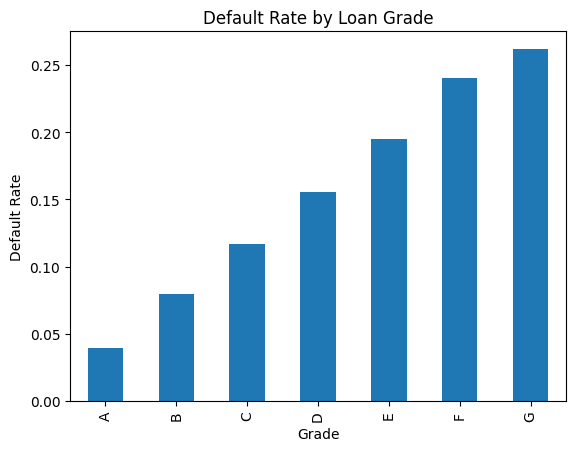

In [15]:
import matplotlib.pyplot as plt

grade_risk = df.groupby('grade')['risk_flag'].mean().sort_values()

grade_risk.plot(kind='bar')
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.xlabel('Grade')
plt.show()

Loan grade merupakan indikator tingkat risiko pinjaman yang ditetapkan oleh pemberi pinjaman berdasarkan profil kredit peminjam. Grade yang lebih rendah (E–G) menunjukkan risiko gagal bayar yang lebih tinggi dibandingkan grade yang lebih tinggi (A–C).

Hasil analisis menunjukkan bahwa tingkat gagal bayar meningkat secara signifikan seiring penurunan loan grade. Pinjaman dengan grade A memiliki default rate di bawah 5%, sedangkan grade G mencapai sekitar 25%, yang berarti pinjaman grade G memiliki risiko gagal bayar sekitar lima kali lebih tinggi dibandingkan grade A.

Semakin buruk loan grade, semakin besar kemungkinan gagal bayar.

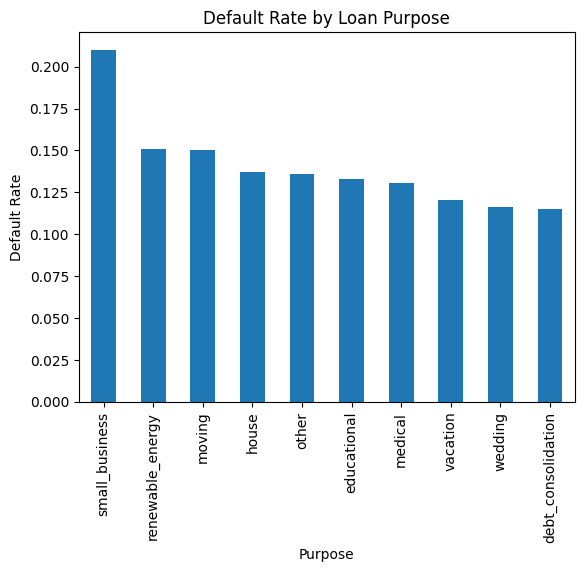

In [16]:
purpose_risk = (
    df.groupby('purpose')['risk_flag']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

purpose_risk.plot(kind='bar')
plt.title('Default Rate by Loan Purpose')
plt.ylabel('Default Rate')
plt.xlabel('Purpose')
plt.show()

Meskipun beberapa tujuan pinjaman bersifat konsumtif, hasil analisis menunjukkan bahwa tujuan pinjaman dengan default rate tertinggi adalah usaha kecil, sementara pinjaman untuk konsolidasi utang justru memiliki tingkat gagal bayar yang relatif lebih rendah. Hal ini mengindikasikan bahwa profil peminjam berperan penting dalam menentukan risiko, bukan hanya tujuan pinjaman itu sendiri.

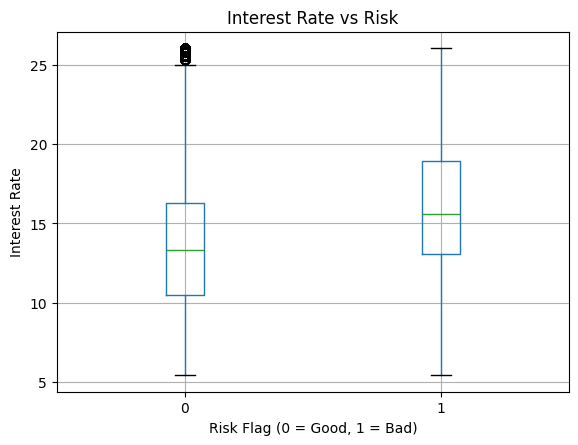

In [17]:
df.boxplot(column='int_rate', by='risk_flag')
plt.title('Interest Rate vs Risk')
plt.suptitle('')
plt.xlabel('Risk Flag (0 = Good, 1 = Bad)')
plt.ylabel('Interest Rate')
plt.show()

Distribusi suku bunga menunjukkan bahwa pinjaman berisiko memiliki tingkat bunga yang lebih tinggi dibandingkan pinjaman tidak berisiko. Meskipun demikian, terdapat overlap antara kedua kelompok, yang mengindikasikan bahwa suku bunga bukan satu-satunya faktor penentu risiko gagal bayar.

In [19]:
# 1. Pilih fitur & target
features = [
    'loan_amnt',
    'int_rate',
    'term',
    'annual_inc',
    'dti',
    'grade',
    'home_ownership',
    'purpose'
]

X = df[features]
y = df['risk_flag']

In [20]:
# 2. One-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [21]:
# 3. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
# 4. Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 5. Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [24]:
# 6. Evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8897026496670492

Confusion Matrix:
 [[82971     1]
 [10285     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     82972
           1       0.00      0.00      0.00     10285

    accuracy                           0.89     93257
   macro avg       0.44      0.50      0.47     93257
weighted avg       0.79      0.89      0.84     93257



Meskipun model logistic regression menghasilkan nilai akurasi yang tinggi, model gagal mengidentifikasi pinjaman berisiko. Hal ini disebabkan oleh ketidakseimbangan kelas, di mana proporsi bad loan jauh lebih kecil dibandingkan good loan.

SOLUSI :
- Data harus balanced
- Evaluasi Ulang
- Threshold tuning sesuai tujuan

In [25]:
import numpy as np
import pandas as pd

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values(by='odds_ratio', ascending=False)
coef_df.head(10)

,feature,coefficient,odds_ratio
1,int_rate,0.661549,1.937791
0,loan_amnt,0.087616,1.091569
26,purpose_small_business,0.085591,1.089361
4,dti,0.055040,1.056582
15,home_ownership_RENT,0.050106,1.051382
5,grade_B,0.034827,1.035441
17,purpose_debt_consolidation,0.031918,1.032433
24,purpose_other,0.023433,1.023710
19,purpose_home_improvement,0.021699,1.021936
18,purpose_educational,0.018091,1.018255


Interest rate, loan amount, dan loan purpose merupakan faktor utama yang memengaruhi risiko gagal bayar.

Hasil interpretasi koefisien menunjukkan bahwa tingkat bunga merupakan faktor paling signifikan dalam meningkatkan risiko gagal bayar, diikuti oleh jumlah pinjaman dan tujuan usaha kecil. Selain itu, rasio utang terhadap pendapatan dan status kepemilikan rumah juga berkontribusi terhadap peningkatan risiko kredit

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)
auc


np.float64(0.6716399838137641)

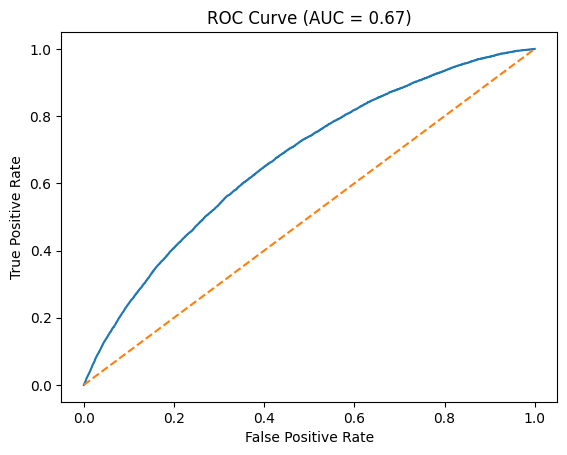

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc:.2f})')
plt.show()

Nilai ROC–AUC sebesar 0.67 menunjukkan bahwa model cukup mampu membedakan antara pinjaman yang berisiko dan yang tidak berisiko. Secara keseluruhan, Logistic Regression dapat digunakan sebagai model dasar untuk analisis risiko kredit dan memberikan gambaran awal yang baik mengenai faktor-faktor yang memengaruhi gagal bayar. Ke depannya, performa model masih dapat ditingkatkan dengan metode yang lebih lanjut.